# Model V5 — AR(1) with Annual Cycle, Per-Region New Year Effect, Full Reset, and Hierarchical Cost-Per-10k Baseline

**Likelihood:**
$$y_{i,1} \sim \mathcal{N}(\mu_{i,1},\, \tau_i)$$
$$y_{i,t} \sim \mathcal{N}\!\Big(\mu_{i,t} + \phi\,(y_{i,t-1} - \mu_{i,t-1}),\, \tau_i\Big), \quad t = 2,\ldots,T$$

**Mean function (same structure as V3):**
$$\mu_{i,t} = \alpha_i + \beta_i \cos\!\Big(\frac{2\pi t}{52}\Big) + \gamma_i \sin\!\Big(\frac{2\pi t}{52}\Big) + $$
$$\delta_{\text{pre},i}\, \mathbb{1}(t\bmod 52 = 0) + \delta_{\text{mid},i}\, \mathbb{1}(t\bmod 52 = 1) + \delta_{\text{post},i}\, \mathbb{1}(t\bmod 52 = 2) + $$
$$\sigma_{\text{pre}}\, \mathbb{1}(t = 86, i=\text{mid west}) + \sigma_{\text{mid}}\, \mathbb{1}(t = 87, i=\text{mid west}) + \sigma_{\text{post}}\, \mathbb{1}(t = 88, i=\text{mid west})$$

**Hierarchical prior on intercept (V4 key change):**
$$\alpha_i \sim \mathcal{N}(\mu_\lambda \cdot c_i,\; \tau_\alpha)$$

where $c_i$ is the HR cost-per-person for region $i$ (from `hr_cost_per_10k.csv`), $\mu_\lambda$ is a global cost coefficient, and $\tau_\alpha$ captures residual region-level variation.

**Other priors:**
$$\beta_i, \gamma_i, \delta_{\text{pre},i}, \delta_{\text{mid},i}, \delta_{\text{post},i} \sim \mathcal{N}(0,\, 10^3) \quad \tau_i \sim \text{Gamma}(0.001,\, 0.001) \quad \phi \sim \text{Uniform}(-1,\, 1)$$
$$\sigma_{\text{pre}},\, \sigma_{\text{mid}},\, \sigma_{\text{post}} \sim \mathcal{N}(0,\, 10^3) \quad \mu_\lambda \sim \mathcal{N}(0,\, 10^3) \quad \tau_\alpha \sim \text{Gamma}(0.001,\, 0.001)$$

**Key difference from V3:** the prior on $\alpha_i$ is centred at $\mu_\lambda \cdot c_i$ — partial pooling toward a cost-scaled expectation rather than a free $\mathcal{N}(0, 10^3)$ prior.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.graphics.tsaplots import plot_acf
import numpy as np
from itertools import combinations

sns.set_theme(style='whitegrid', font_scale=1.2)

# Load raw MCMC samples and observed data
df_og = pd.read_csv('../../data/wide_weekly_scaledPer10k.csv')
raw_df = pd.read_csv('../../data/models/v5/raw_samples.csv')
regions = pd.read_csv('../../data/regions.csv')['region'].tolist()
n_region = len(regions)

# Cost-per-person (the scaler c_i)
cpp_df = pd.read_csv('../../data/hseBudget_scaledPer10k.csv')
cost_per_10k_raw = cpp_df.set_index('Region').loc[regions, 'BudgetPer10k'].values

# Rescale: divide by 1000 so units = thousands of euro per 10k pop (matches Rmd)
cost_per_10k = cost_per_10k_raw / 1000

# mu_global posterior samples (new hyperprior from partial pooling)
mu_global_samples = raw_df['mu_global'].values

pd.DataFrame({'Region': regions, 'BudgetPer10k_raw': cost_per_10k_raw.round(4), 'BudgetPer10k_k': cost_per_10k.round(4)})

,Region,BudgetPer10k_raw,BudgetPer10k_k
0,HSE Dublin and Midlands,34055.9315,34.0559
1,HSE Dublin and North East,28599.5407,28.5995
2,HSE Dublin and South East,27381.5175,27.3815
3,HSE Mid West,28615.7668,28.6158
4,HSE South West,27031.6251,27.0316
5,HSE West and North West,33067.7731,33.0678


## HR Cost Per Person by Region

Per-capita HR budget allocation for each HSE region.

**Units:** € thousands per person (k€/person) — total regional HR budget (€) divided by catchment population.

In [2]:
cpp_display = pd.read_csv('../../data/hseBudget_scaledPer10k.csv')
cpp_display = cpp_display.set_index('Region').loc[regions].reset_index()
cpp_display.columns = ['Region', 'Budget Per 10k (k€/person)']
cpp_display['Budget Per 10k (k€/person)'] = cpp_display['Budget Per 10k (k€/person)'].round(4)
cpp_display.sort_values('Budget Per 10k (k€/person)', ascending=False)

,Region,Budget Per 10k (k€/person)
0,HSE Dublin and Midlands,34055.9315
5,HSE West and North West,33067.7731
3,HSE Mid West,28615.7668
1,HSE Dublin and North East,28599.5407
2,HSE Dublin and South East,27381.5175
4,HSE South West,27031.6251


## Load the model parameters

In [3]:
n_weeks = df_og.shape[1] - 1  # exclude Region column

# Time vector (1-based, matching R)
t_vec = np.arange(1, n_weeks + 1)

# Event indicators (matching R model specification)
week_mod = t_vec % 52
ny_pre  = (week_mod == 0).astype(float)
ny_mid  = (week_mod == 1).astype(float)
ny_post = (week_mod == 2).astype(float)
fr_pre  = (t_vec == 86).astype(float)
fr_mid  = (t_vec == 87).astype(float)
fr_post = (t_vec == 88).astype(float)

# Mid West mask
mw = np.array([1.0 if r == 'HSE Mid West' else 0.0 for r in regions])

# Trig components
cos_t = np.cos(2 * np.pi * t_vec / 52)
sin_t = np.sin(2 * np.pi * t_vec / 52)

# Compute mu[i,t]: V5 uses alpha[i] directly (hierarchical prior centred on mu_lambda * c_i)
mu_mean_arr  = np.zeros((n_weeks, n_region))
mu_lower_arr = np.zeros((n_weeks, n_region))
mu_upper_arr = np.zeros((n_weeks, n_region))

for i in range(n_region):
    mu_i = (raw_df[f'alpha[{i+1}]'].values[:, None]
            + raw_df[f'beta[{i+1}]'].values[:, None]      * cos_t[None, :]
            + raw_df[f'gamma[{i+1}]'].values[:, None]     * sin_t[None, :]
            + raw_df[f'delta_pre[{i+1}]'].values[:, None] * ny_pre[None, :]
            + raw_df[f'delta_mid[{i+1}]'].values[:, None] * ny_mid[None, :]
            + raw_df[f'delta_post[{i+1}]'].values[:, None]* ny_post[None, :]
            + raw_df['sigma_pre'].values[:, None]  * (fr_pre  * mw[i])[None, :]
            + raw_df['sigma_mid'].values[:, None]  * (fr_mid  * mw[i])[None, :]
            + raw_df['sigma_post'].values[:, None] * (fr_post * mw[i])[None, :])
    mu_mean_arr[:, i]  = mu_i.mean(axis=0)
    mu_lower_arr[:, i] = np.quantile(mu_i, 0.025, axis=0)
    mu_upper_arr[:, i] = np.quantile(mu_i, 0.975, axis=0)

df_mu       = pd.DataFrame(mu_mean_arr,  columns=regions)
df_mu_lower = pd.DataFrame(mu_lower_arr, columns=regions)
df_mu_upper = pd.DataFrame(mu_upper_arr, columns=regions)

phi_mean = raw_df['phi'].mean()

## Preprocess
Transform the og df into regions (cols) x time (weeks)

In [4]:
df_og = df_og.T
df_og.columns = df_og.iloc[0]
df_og = df_og.drop(df_og.index[0])
df_og = df_og.reset_index(drop=True)

## Make the model estimate df
Formula
y[i,t] ~ dnorm(mu[i,t] + (phi * (y[i,t-1] - mu[i,t-1])), tau[i])

In [5]:
df_mu_t1    = df_mu.iloc[:df_mu.shape[0]-1]
df_og_t1    = df_og.iloc[:df_mu.shape[0]-1]
phi         = phi_mean
df_mu_first = pd.DataFrame([df_mu.iloc[0]])
df_mu_rest  = df_mu.iloc[1:].reset_index(drop=True)
df_ar1 = df_mu_rest + (phi * (df_og_t1 - df_mu_t1))
df_ar1 = pd.concat([df_mu_first, df_ar1], ignore_index=True)
df_ar1

,HSE Dublin and Midlands,HSE Dublin and North East,HSE Dublin and South East,HSE Mid West,HSE South West,HSE West and North West
0,0.860423,0.58235,0.862362,2.554413,1.332737,1.695889
1,4.810308,2.914334,3.662442,7.226398,5.766097,7.966716
2,6.2658,4.460482,5.200997,7.263162,6.227307,8.190406
3,5.358377,3.210208,4.24227,5.284334,5.119316,6.254011
4,5.208087,2.630679,3.622155,5.845994,5.125983,7.534529
...,...,...,...,...,...,...
146,2.942829,1.948087,2.955847,7.23324,5.090131,6.676867
147,2.50145,1.717308,3.106147,5.60464,5.431813,5.301785
148,2.532113,1.768666,3.070808,5.097639,4.575608,5.839921
149,2.942243,1.912537,3.005906,5.456292,5.107589,5.351871


## Plot MU
This should look like yearly oscillations

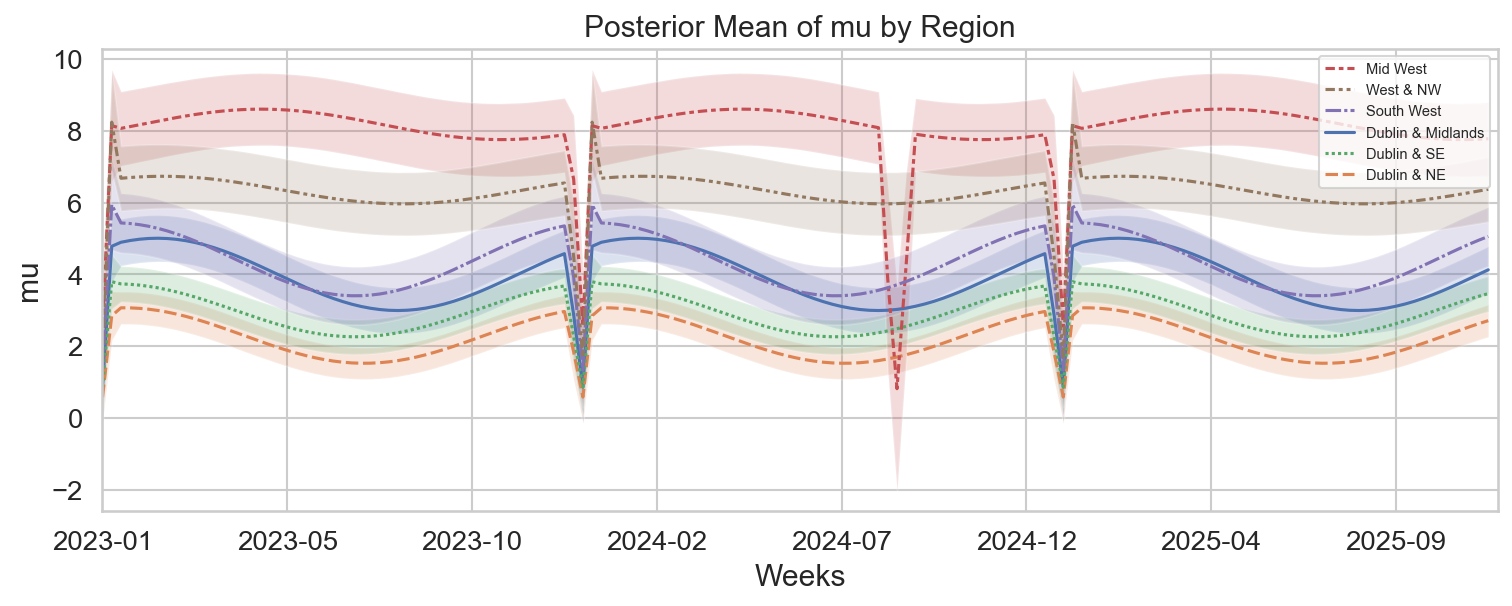

In [6]:
plt.figure(figsize=(12, 4), dpi=150)
short_names = {
    'HSE Dublin and Midlands': 'Dublin & Midlands',
    'HSE Dublin and North East': 'Dublin & NE',
    'HSE Dublin and South East': 'Dublin & SE',
    'HSE Mid West': 'Mid West',
    'HSE South West': 'South West',
    'HSE West and North West': 'West & NW',
}

axs = sns.lineplot(data=df_mu)
for col in df_mu.columns:
    plt.fill_between(df_mu.index, df_mu_lower[col], df_mu_upper[col], alpha=0.2)
axs.set_title('Posterior Mean of mu by Region')
axs.set_xlabel('Weeks')
axs.set_ylabel('mu')
axs.set_xlim(0, df_mu.shape[0])
axs.set_xticks(df_mu.index[::20])
x_labels = pd.to_datetime('2023-01-01') + pd.to_timedelta(df_mu.index, unit='W')
x_labels = x_labels.strftime('%Y-%m')
axs.set_xticklabels(x_labels[::20])

# Sort legend by mean value (descending)
handles, labels = plt.gca().get_legend_handles_labels()
mean_vals = {lab: df_mu[lab].mean() for lab in labels}
order = sorted(range(len(labels)), key=lambda i: mean_vals[labels[i]], reverse=True)
plt.legend([handles[i] for i in order], [short_names.get(labels[i], labels[i]) for i in order], loc='upper right', fontsize=7)
plt.savefig('../../data/models/v5/plots/mu_fit.png', bbox_inches='tight', dpi=150)
plt.show()


## Alpha baseline & cost-scaled expectation

$\alpha_i$ is the region-specific intercept estimated with the hierarchical prior $\alpha_i \sim \mathcal{N}(\mu_\lambda \cdot c_i, \tau_\alpha)$.

**CostScaled** = $\hat{\mu}_\lambda \cdot c_i$ (what the model expects given per-capita cost alone).  
**Deviation** = $\hat{\alpha}_i - \hat{\mu}_\lambda \cdot c_i$ (how much each region's intercept departs from the cost-scaled expectation).

In [7]:
# Full posterior sample matrices — shape: (n_samples, n_region)
alpha_samples       = np.column_stack([raw_df[f'alpha[{i+1}]'].values for i in range(n_region)])
mu_lambda_samples   = np.column_stack([raw_df[f'mu_lambda[{i+1}]'].values for i in range(n_region)])

# cost_per_10k is already rescaled (/1000) — broadcast: (n_samples, n_region) * (n_region,)
cost_scaled_samples = mu_lambda_samples * cost_per_10k  # (n_samples, n_region)
deviation_samples = alpha_samples - cost_scaled_samples  # (n_samples, n_region)

df_alpha = pd.DataFrame({
    'Alpha_Mean':      alpha_samples.mean(axis=0),
    'Alpha_2.5%':      np.quantile(alpha_samples, 0.025, axis=0),
    'Alpha_97.5%':     np.quantile(alpha_samples, 0.975, axis=0),
    'CostScaled_Mean': cost_scaled_samples.mean(axis=0),
    'CostScaled_2.5%': np.quantile(cost_scaled_samples, 0.025, axis=0),
    'CostScaled_97.5%':np.quantile(cost_scaled_samples, 0.975, axis=0),
    'Deviation_Mean':  deviation_samples.mean(axis=0),
    'Deviation_2.5%':  np.quantile(deviation_samples, 0.025, axis=0),
    'Deviation_97.5%': np.quantile(deviation_samples, 0.975, axis=0),
    'mu_global_Mean':  mu_global_samples.mean(),
    'mu_global_2.5%':  np.quantile(mu_global_samples, 0.025),
    'mu_global_97.5%': np.quantile(mu_global_samples, 0.975),
}, index=regions)

df_alpha.sort_values('Alpha_Mean', ascending=False).round(3)

,Alpha_Mean,Alpha_2.5%,Alpha_97.5%,CostScaled_Mean,CostScaled_2.5%,CostScaled_97.5%,Deviation_Mean,Deviation_2.5%,Deviation_97.5%,mu_global_Mean,mu_global_2.5%,mu_global_97.5%
HSE Mid West,8.181,7.572,8.782,7.454,3.680,9.168,0.728,-0.870,4.533,0.158,0.073,0.245
HSE West and North West,6.351,5.830,6.875,6.157,3.508,8.155,0.194,-1.765,2.823,0.158,0.073,0.245
HSE South West,4.420,3.938,4.900,4.399,2.302,6.439,0.021,-2.003,2.115,0.158,0.073,0.245
HSE Dublin and Midlands,4.001,3.623,4.383,4.252,2.351,7.065,-0.250,-3.051,1.639,0.158,0.073,0.245
HSE Dublin and South East,3.000,2.711,3.289,3.285,1.564,5.900,-0.284,-2.903,1.422,0.158,0.073,0.245
HSE Dublin and North East,2.297,2.037,2.556,2.754,1.114,5.833,-0.456,-3.534,1.169,0.158,0.073,0.245


In [8]:

df_alpha = pd.DataFrame({
    'CostScaled_Mean': cost_scaled_samples.mean(axis=0),
    'CostScaled_2.5%': np.quantile(cost_scaled_samples, 0.025, axis=0),
    'CostScaled_97.5%':np.quantile(cost_scaled_samples, 0.975, axis=0),
}, index=regions)

df_alpha.sort_values('CostScaled_Mean', ascending=False).round(3)

,CostScaled_Mean,CostScaled_2.5%,CostScaled_97.5%
HSE Mid West,7.454,3.680,9.168
HSE West and North West,6.157,3.508,8.155
HSE South West,4.399,2.302,6.439
HSE Dublin and Midlands,4.252,2.351,7.065
HSE Dublin and South East,3.285,1.564,5.900
HSE Dublin and North East,2.754,1.114,5.833


In [9]:
df_alpha = pd.DataFrame({
    'Deviation_Mean':  deviation_samples.mean(axis=0),
    'Deviation_2.5%':  np.quantile(deviation_samples, 0.025, axis=0),
    'Deviation_97.5%': np.quantile(deviation_samples, 0.975, axis=0),
}, index=regions)

df_alpha.sort_values('Deviation_Mean', ascending=False).round(3)

,Deviation_Mean,Deviation_2.5%,Deviation_97.5%
HSE Mid West,0.728,-0.870,4.533
HSE West and North West,0.194,-1.765,2.823
HSE South West,0.021,-2.003,2.115
HSE Dublin and Midlands,-0.250,-3.051,1.639
HSE Dublin and South East,-0.284,-2.903,1.422
HSE Dublin and North East,-0.456,-3.534,1.169


## Plot model fit

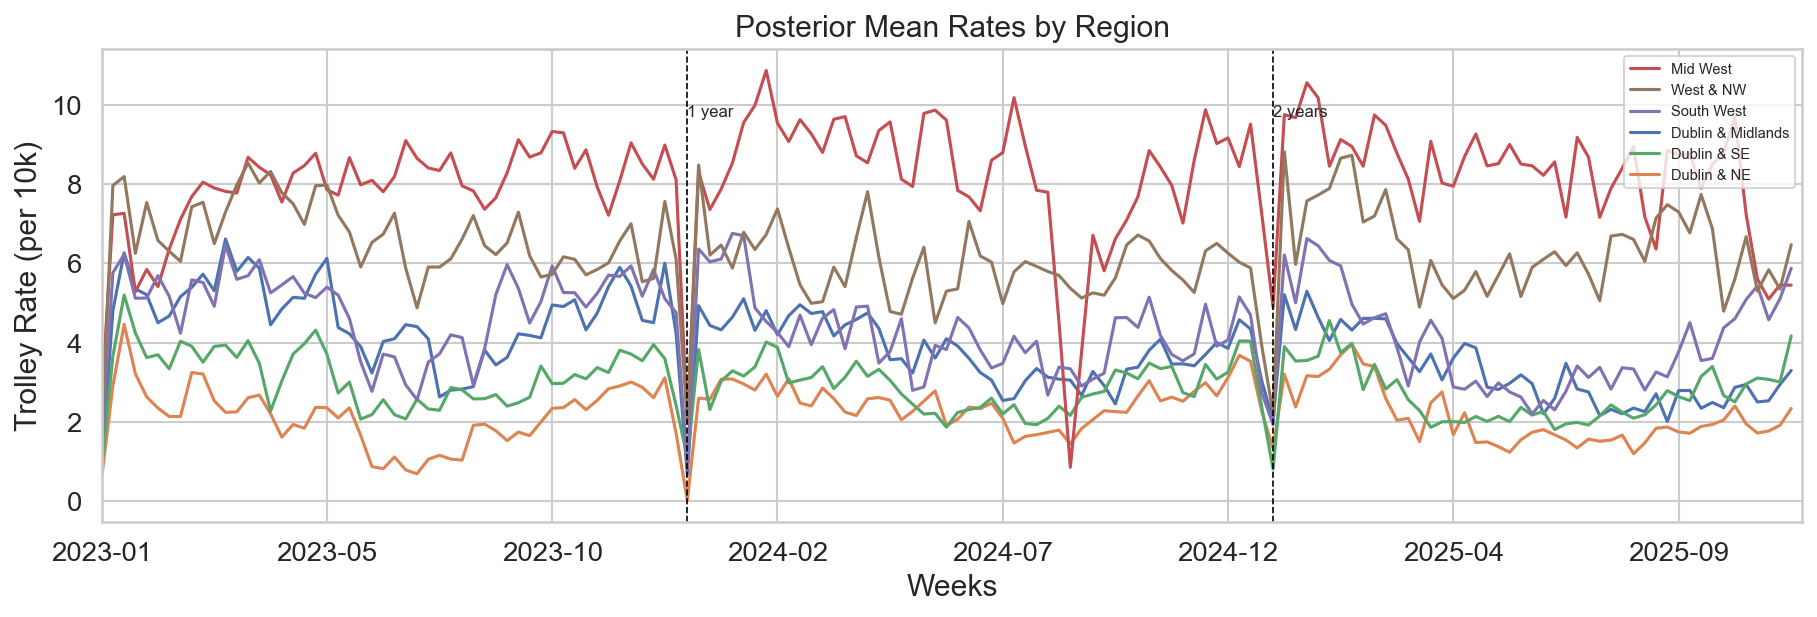

In [10]:
fig, ax = plt.subplots(figsize=(12, 4), dpi=150, layout='constrained')
short_names = {
    'HSE Dublin and Midlands': 'Dublin & Midlands',
    'HSE Dublin and North East': 'Dublin & NE',
    'HSE Dublin and South East': 'Dublin & SE',
    'HSE Mid West': 'Mid West',
    'HSE South West': 'South West',
    'HSE West and North West': 'West & NW',
}

for col in df_ar1.columns:
    ax.plot(df_ar1.index, df_ar1[col], label=col)
ax.axvline(x=104, color='black', linestyle='--', linewidth=0.8)
ax.axvline(x=52, color='black', linestyle='--', linewidth=0.8)
ax.annotate('2 years', xy=(104, ax.get_ylim()[1]*0.85), fontsize=8)
ax.annotate('1 year', xy=(52, ax.get_ylim()[1]*0.85), fontsize=8)
ax.set_xlim(0, df_ar1.shape[0])
ax.set_title('Posterior Mean Rates by Region')
ax.set_xlabel('Weeks')
ax.set_ylabel('Trolley Rate (per 10k)')
ax.set_xticks(df_ar1.index[::20])
x_labels = pd.to_datetime('2023-01-01') + pd.to_timedelta(df_ar1.index, unit='W')
ax.set_xticklabels(x_labels.strftime('%Y-%m')[::20])

handles, labels = ax.get_legend_handles_labels()
mean_vals = {lab: df_ar1[lab].mean() for lab in labels}
order = sorted(range(len(labels)), key=lambda i: mean_vals[labels[i]], reverse=True)
ax.legend([handles[i] for i in order], [short_names.get(labels[i], labels[i]) for i in order], loc='upper right', fontsize=7)
fig.savefig('../../data/models/v5/plots/ar1_fit.png', bbox_inches='tight', dpi=150)
plt.show()


## Plot the residuals

In [11]:
df_residuals = df_og - df_ar1
df_std_resid = df_residuals / df_residuals.std()

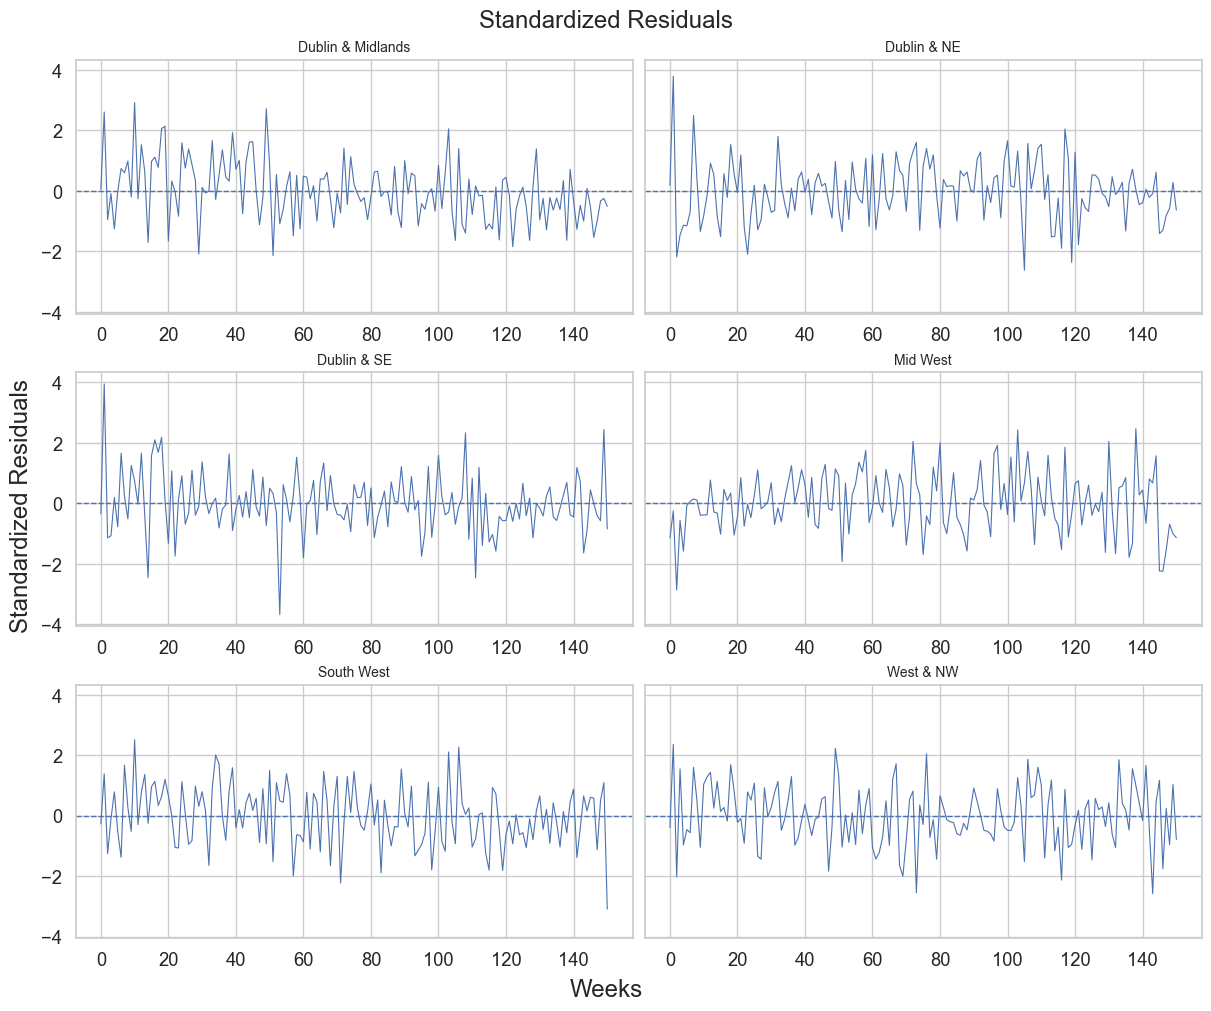

In [12]:
short_names = {
    'HSE Dublin and Midlands': 'Dublin & Midlands',
    'HSE Dublin and North East': 'Dublin & NE',
    'HSE Dublin and South East': 'Dublin & SE',
    'HSE Mid West': 'Mid West',
    'HSE South West': 'South West',
    'HSE West and North West': 'West & NW',
}

fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharey=True, layout='constrained')
for col, ax in zip(df_std_resid.columns, axes.flatten()):
    ax.plot(df_std_resid[col], linewidth=0.8)
    ax.axhline(y=0, linestyle='--', linewidth=1)
    ax.set_title(short_names.get(col, col), fontsize=10)
    ax.set_ylabel('')
    ax.set_xlabel('')
fig.suptitle('Standardized Residuals')
fig.supxlabel('Weeks')
fig.supylabel('Standardized Residuals')
fig.savefig('../../data/models/v5/plots/residuals_ts.png', bbox_inches='tight', dpi=150)
plt.show()


### Autocorrelation of Residuals

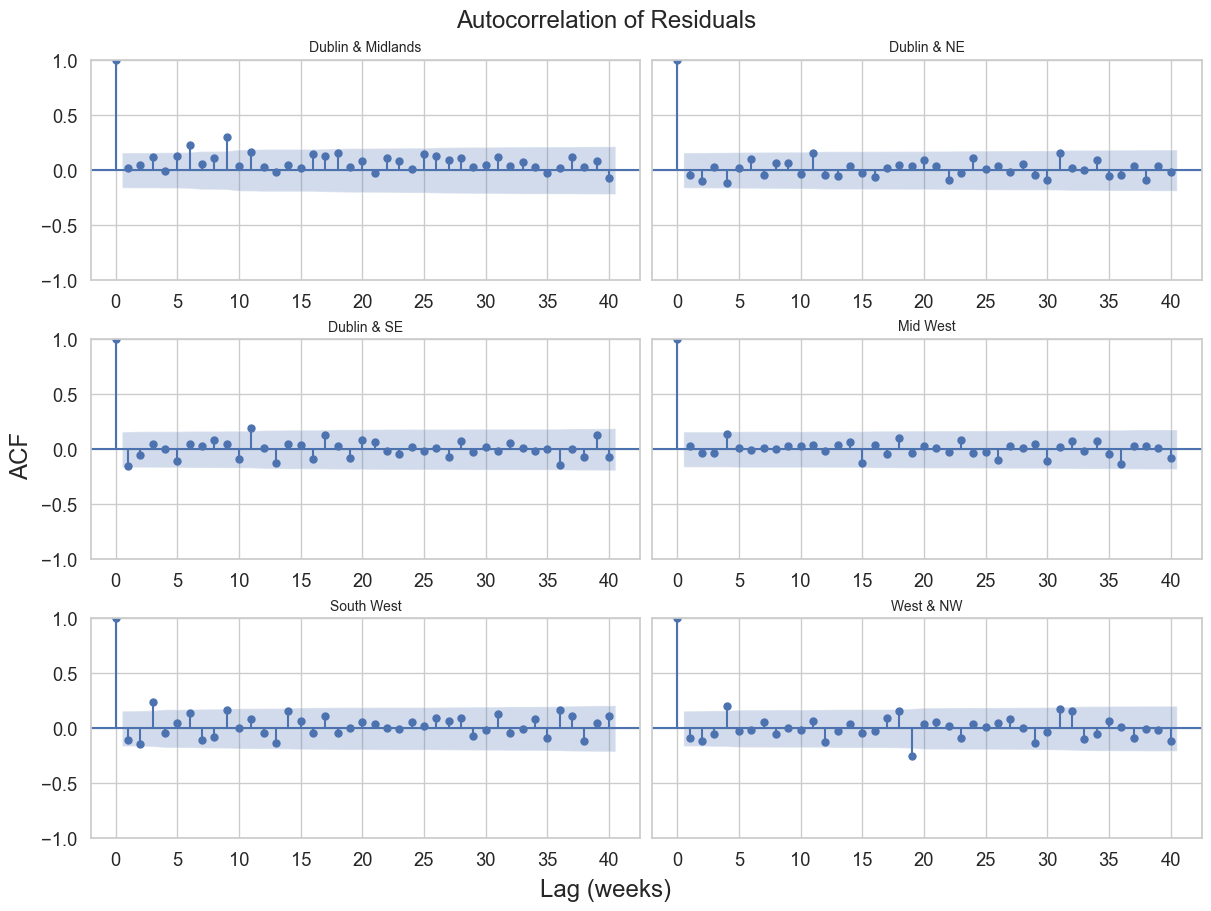

In [13]:
short_names = {
    'HSE Dublin and Midlands': 'Dublin & Midlands',
    'HSE Dublin and North East': 'Dublin & NE',
    'HSE Dublin and South East': 'Dublin & SE',
    'HSE Mid West': 'Mid West',
    'HSE South West': 'South West',
    'HSE West and North West': 'West & NW',
}

fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharey=True, layout='constrained')
for ax, col in zip(axes.flatten(), df_std_resid.columns):
    plot_acf(df_std_resid[col].dropna(), ax=ax, lags=40, alpha=0.05)
    ax.set_title(short_names.get(col, col), fontsize=10)
    ax.set_ylabel('')
    ax.set_xlabel('')
fig.suptitle('Autocorrelation of Residuals')
fig.supxlabel('Lag (weeks)')
fig.supylabel('ACF')
fig.savefig('../../data/models/v5/plots/residuals_acf.png', bbox_inches='tight', dpi=150)
plt.show()


### Residuals vs Fitted

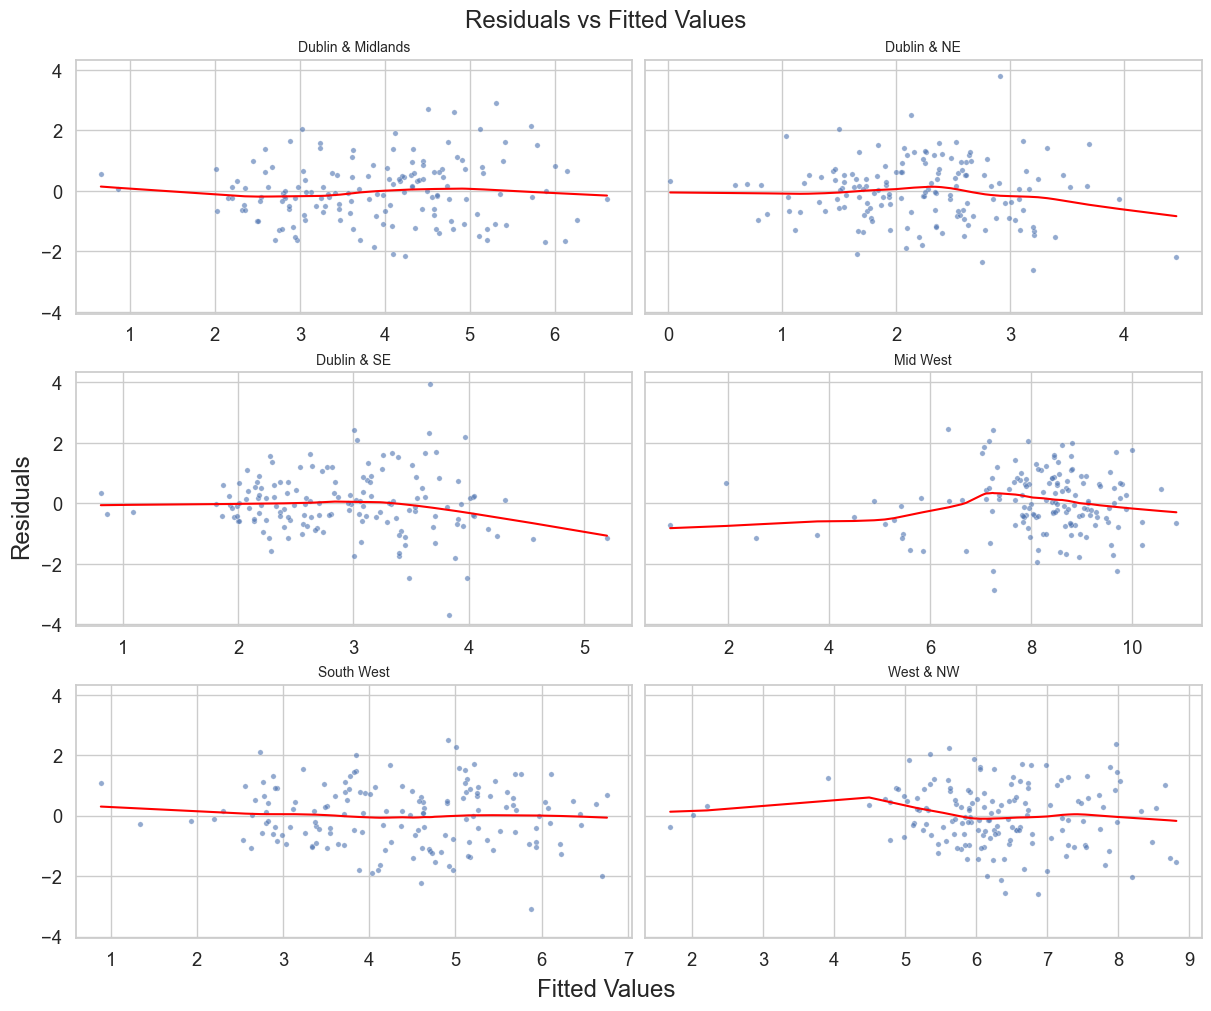

In [14]:
short_names = {
    'HSE Dublin and Midlands': 'Dublin & Midlands',
    'HSE Dublin and North East': 'Dublin & NE',
    'HSE Dublin and South East': 'Dublin & SE',
    'HSE Mid West': 'Mid West',
    'HSE South West': 'South West',
    'HSE West and North West': 'West & NW',
}

fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharey=True, layout='constrained')
for col, ax in zip(df_std_resid.columns, axes.flatten()):
    sns.scatterplot(x=df_ar1[col], y=df_std_resid[col], ax=ax, s=15, alpha=0.6)
    smooth = lowess(df_std_resid[col], df_ar1[col], frac=2/3, return_sorted=True)
    sns.lineplot(x=smooth[:, 0], y=smooth[:, 1], ax=ax, color='red')
    ax.set_title(short_names.get(col, col), fontsize=10)
    ax.set_ylabel('')
    ax.set_xlabel('')
fig.suptitle('Residuals vs Fitted Values')
fig.supxlabel('Fitted Values')
fig.supylabel('Residuals')
fig.savefig('../../data/models/v5/plots/residuals_vs_fitted.png', bbox_inches='tight', dpi=150)
plt.show()


### QQ-Plot For Residuals

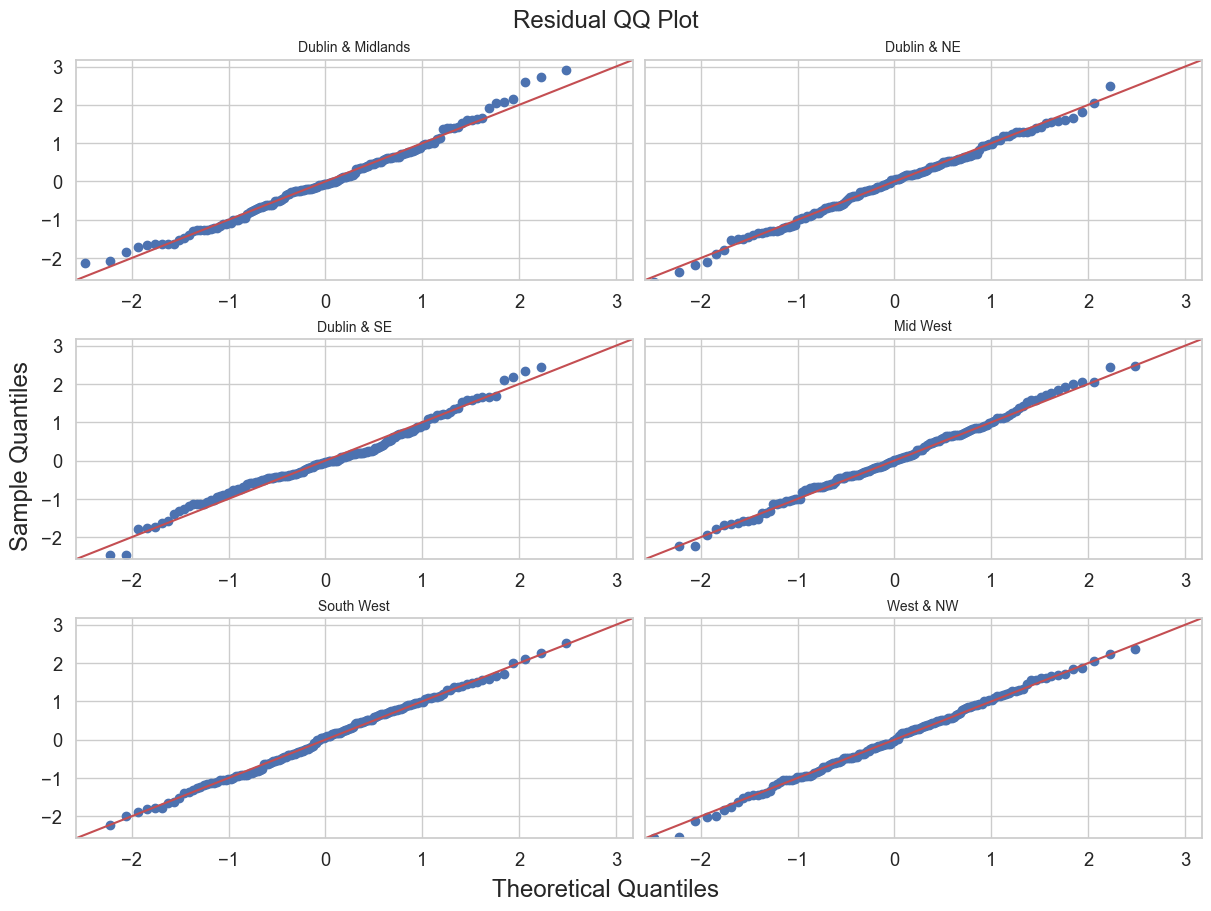

In [15]:
short_names = {
    'HSE Dublin and Midlands': 'Dublin & Midlands',
    'HSE Dublin and North East': 'Dublin & NE',
    'HSE Dublin and South East': 'Dublin & SE',
    'HSE Mid West': 'Mid West',
    'HSE South West': 'South West',
    'HSE West and North West': 'West & NW',
}

fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharey=True, layout='constrained')
for ax, col in zip(axes.flatten(), df_std_resid.columns):
    qqplot(df_std_resid[col], line='45', ax=ax)
    ax.set_title(short_names.get(col, col), fontsize=10)
    ax.set_ylabel('')
    ax.set_xlabel('')
fig.suptitle('Residual QQ Plot')
fig.supxlabel('Theoretical Quantiles')
fig.supylabel('Sample Quantiles')
fig.savefig('../../data/models/v5/plots/residuals_qq.png', bbox_inches='tight', dpi=150)
plt.show()


# Significance Testing

### Bonferroni correction

In [16]:
def calc_bonf(n_comparisons, one_sided=False):
    alpha = 0.05 / n_comparisons
    if one_sided:
        lower_q = alpha
        upper_q = 1 - alpha
    else:
        lower_q = alpha / 2
        upper_q = 1 - alpha / 2
    side = "one-sided" if one_sided else "two-sided"
    print(f"n_comparisons={n_comparisons}, alpha={alpha:.6f}, "
          f"lower_q={lower_q:.6f}, upper_q={upper_q:.6f} ({side})")
    return alpha, lower_q, upper_q

### Annual cycle amplitude
$$\hat{A} = \sqrt{\beta^2 + \gamma^2}$$

- Tests whether the seasonal cycle has a practically meaningful magnitude
- $P(A_i > \varepsilon)$ where $\varepsilon = 0.5$ trolleys per 10k
- No hypothesis test — direct posterior probability statement

In [17]:
samples = raw_df.filter(regex='beta|gamma')

ampl = {}
for i in range(n_region):
    b = samples[f'beta[{i+1}]']
    g = samples[f'gamma[{i+1}]']
    ampl[regions[i]] = np.sqrt(b**2 + g**2)

In [18]:
epsilon = 0.5  # minimum meaningful amplitude (trolleys per 10k)

results = []
for region in regions:
    a = ampl[region]
    post_p = (a > epsilon).mean()
    results.append({
        'Region':        region,
        'Mean A':        round(a.mean(), 3),
        'Median A':      round(np.median(a), 3),
        '2.5%':          round(np.quantile(a, 0.025), 3),
        '97.5%':         round(np.quantile(a, 0.975), 3),
        f'P(A > {epsilon})': round(post_p, 3),
    })

df_ampl_overall = pd.DataFrame(results).sort_values(f'P(A > {epsilon})', ascending=False)
df_ampl_overall.to_csv('../../data/models/v5/amplitude_overall.csv', index=False)
df_ampl_overall


,Region,Mean A,Median A,2.5%,97.5%,P(A > 0.5)
0,HSE Dublin and Midlands,1.042,1.041,0.542,1.549,0.983
4,HSE South West,1.072,1.069,0.442,1.712,0.962
1,HSE Dublin and North East,0.795,0.794,0.448,1.148,0.952
2,HSE Dublin and South East,0.766,0.764,0.382,1.155,0.914
3,HSE Mid West,0.645,0.613,0.120,1.361,0.634
5,HSE West and North West,0.574,0.547,0.108,1.197,0.563


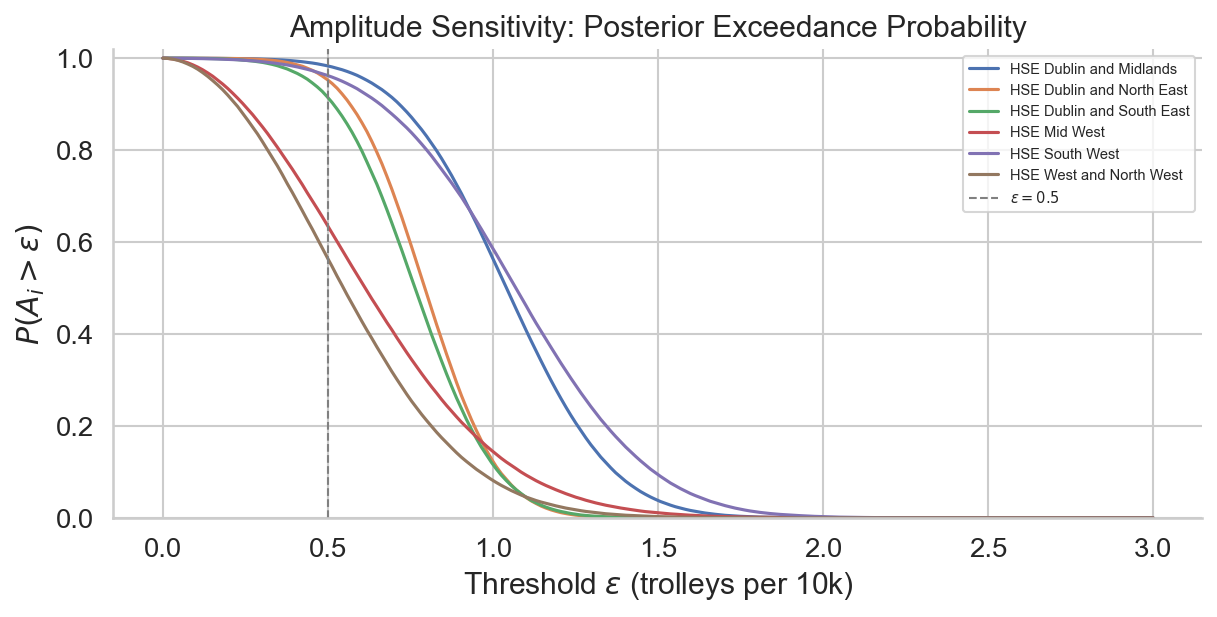

In [19]:
# Sensitivity: P(A > epsilon) across a range of thresholds
epsilons = np.linspace(0, 3, 200)

fig, ax = plt.subplots(figsize=(8, 4), dpi=150, layout='constrained')
for region in regions:
    probs = [(ampl[region] > e).mean() for e in epsilons]
    ax.plot(epsilons, probs, label=region)

ax.axvline(0.5, linestyle='--', color='grey', linewidth=1, label=r'$\varepsilon = 0.5$')
ax.set_xlabel(r'Threshold $\varepsilon$ (trolleys per 10k)')
ax.set_ylabel(r'$P(A_i > \varepsilon)$')
ax.set_title('Amplitude Sensitivity: Posterior Exceedance Probability')
ax.legend(fontsize=7, loc='upper right')
ax.set_ylim(0, 1.02)
sns.despine()
fig.savefig('../../data/models/v5/plots/amplitude_overall.png', bbox_inches='tight', dpi=150)
plt.show()

### Annual cycle amplitude — pairwise

In [20]:
epsilon = 0.5  # minimum meaningful amplitude difference (trolleys per 10k)

results = []
for r1, r2 in combinations(range(n_region), 2):
    diff = ampl[regions[r1]] - ampl[regions[r2]]
    p_dir = (diff > 0).mean()
    prob = (np.abs(diff) > epsilon).mean()
    results.append({
        'Region1': regions[r1], 'Region2': regions[r2],
        'MeanDiff': diff.mean(),
        f'P(|diff| > {epsilon})': round(prob, 3),
        'P(diff > 0)': round(p_dir, 3),
        'P(diff < 0)': round(1 - p_dir, 3),
    })

df_ampl_pw = pd.DataFrame(results).round(3)
df_ampl_pw.to_csv('../../data/models/v5/amplitude_pairwise.csv', index=False)
df_ampl_pw


,Region1,Region2,MeanDiff,P(|diff| > 0.5),P(diff > 0),P(diff < 0)
0,HSE Dublin and Midlands,HSE Dublin and North East,0.248,0.218,0.788,0.212
1,HSE Dublin and Midlands,HSE Dublin and South East,0.277,0.252,0.805,0.195
2,HSE Dublin and Midlands,HSE Mid West,0.397,0.441,0.832,0.168
3,HSE Dublin and Midlands,HSE South West,-0.030,0.226,0.471,0.529
4,HSE Dublin and Midlands,HSE West and North West,0.469,0.493,0.885,0.115
5,HSE Dublin and North East,HSE Dublin and South East,0.029,0.061,0.545,0.455
6,HSE Dublin and North East,HSE Mid West,0.150,0.226,0.674,0.326
7,HSE Dublin and North East,HSE South West,-0.278,0.289,0.227,0.773
8,HSE Dublin and North East,HSE West and North West,0.221,0.232,0.753,0.247
9,HSE Dublin and South East,HSE Mid West,0.121,0.220,0.644,0.356


In [21]:
# Pairwise heatmap helper
short_names = {
    'HSE Dublin and Midlands': 'Dub & Mid',
    'HSE Dublin and North East': 'Dub & NE',
    'HSE Dublin and South East': 'Dub & SE',
    'HSE Mid West': 'Mid West',
    'HSE South West': 'South West',
    'HSE West and North West': 'West & NW',
}

def pairwise_heatmap(df_pw, col, title, save_name, r1_col='Region1', r2_col='Region2',
                     vmin=0, vmax=1, cmap='RdBu_r', fmt='.2f'):
    """Triangular heatmap from a pairwise DataFrame."""
    labels = sorted(set(df_pw[r1_col]) | set(df_pw[r2_col]))
    short = [short_names.get(l, l) for l in labels]
    n = len(labels)
    mat = np.full((n, n), np.nan)
    idx = {l: i for i, l in enumerate(labels)}
    for _, row in df_pw.iterrows():
        i, j = idx[row[r1_col]], idx[row[r2_col]]
        mat[i, j] = row[col]
        mat[j, i] = 1 - row[col] if vmax == 1 else -row[col]


    fig, ax = plt.subplots(figsize=(7, 6), dpi=150, layout='constrained')
    sns.heatmap(mat, annot=True, fmt=fmt, cmap=cmap,
                vmin=vmin, vmax=vmax, square=True, linewidths=0.5,
                xticklabels=short, yticklabels=short, ax=ax,
                cbar_kws={'label': col, 'shrink': 0.8})
    ax.set_title(title, fontsize=12, fontweight='bold')
    fig.savefig(f'../../data/models/v5/plots/{save_name}.png', bbox_inches='tight', dpi=150)
    plt.show()


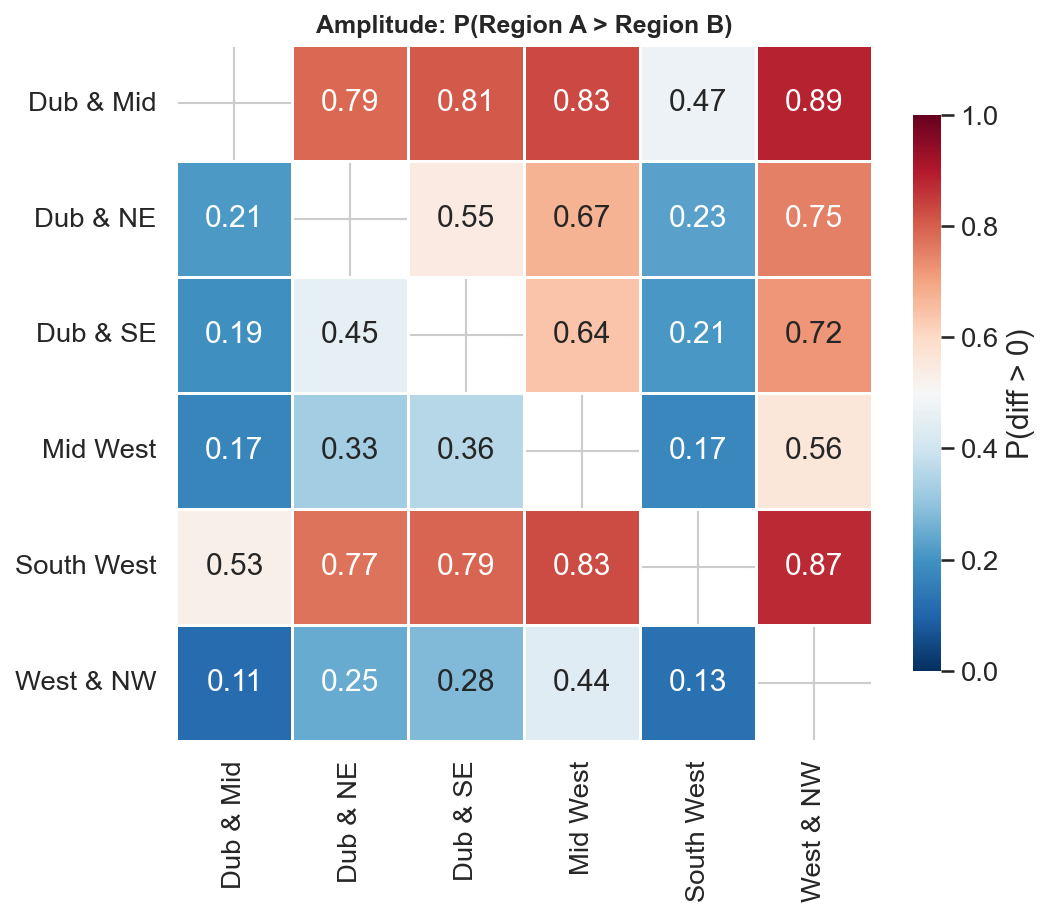

In [22]:
pairwise_heatmap(df_ampl_pw, 'P(diff > 0)',
                 'Amplitude: P(Region A > Region B)',
                 'amplitude_pairwise')


### Phase cycles — overall test

The seasonal component is $\beta_i \cos\\!\Big(\frac{2\pi t}{52}\Big) + \gamma_i \sin\\!\Big(\frac{2\pi t}{52}\Big)$, which peaks when:

$$t_{\text{peak}} = \frac{52}{2\pi}\;\text{arctan2}(\gamma_i,\, \beta_i)$$

We use `arctan2` instead of `arctan` because `arctan(γ/β)` only returns values in $(-\pi/2,\, \pi/2)$ — it cannot distinguish which quadrant the angle falls in:

```
# arctan loses quadrant information:
arctan( 1 /  1) =  pi/4   # Q1 — correct
arctan(-1 / -1) =  pi/4   # Q3 — WRONG, should be -3*pi/4

# arctan2 preserves it by taking (y, x) separately:
arctan2( 1,  1) =  pi/4   # Q1 ✓
arctan2(-1, -1) = -3*pi/4 # Q3 ✓
```

This matters because $\beta$ and $\gamma$ can both be negative (peak in summer), and `arctan(γ/β)` would collapse that to the same angle as both positive (peak in winter).

In [23]:
# Peak of beta*cos(2*pi*t/52) + gamma*sin(2*pi*t/52) at t = (52/2pi)*arctan2(gamma, beta)
# Descriptive 95% CIs — no multiple-testing correction (not a hypothesis test)
ci_lower_q, ci_upper_q = 0.025, 0.975

results = []
for i, region in enumerate(regions):
    b = raw_df[f'beta[{i+1}]'].values
    g = raw_df[f'gamma[{i+1}]'].values
    phase = np.arctan2(g, b)  # radians, in [-pi, pi]
    lo_rad, hi_rad = np.quantile(phase, [ci_lower_q, ci_upper_q])
    mean_wk = ((52 / (2 * np.pi)) * phase.mean()) % 52
    lo_wk = ((52 / (2 * np.pi)) * lo_rad) % 52
    hi_wk = ((52 / (2 * np.pi)) * hi_rad) % 52

    # CI width on the circle (accounts for wrapping)
    ci_width = (hi_wk - lo_wk) % 52

    results.append({
        'Region': region,
        'Mean Peak Week': round(mean_wk, 1),
        '2.5%': round(lo_wk, 1),
        '97.5%': round(hi_wk, 1),
        'CI Width': round(ci_width, 1),
        'Identifiable': 'No' if ci_width > 40 else 'Yes',
    })

df_phase_overall = pd.DataFrame(results).sort_values('Mean Peak Week')
df_phase_overall.to_csv('../../data/models/v5/phase_overall.csv', index=False)
df_phase_overall


,Region,Mean Peak Week,2.5%,97.5%,CI Width,Identifiable
2,HSE Dublin and South East,2.4,49.7,7.0,9.3,Yes
4,HSE South West,2.4,48.7,8.2,11.5,Yes
1,HSE Dublin and North East,3.3,51.4,7.3,7.9,Yes
5,HSE West and North West,6.0,31.7,22.3,42.6,No
0,HSE Dublin and Midlands,7.0,2.5,11.5,8.9,Yes
3,HSE Mid West,9.5,27.0,25.1,50.1,No


### Peak week forest plot — winter band

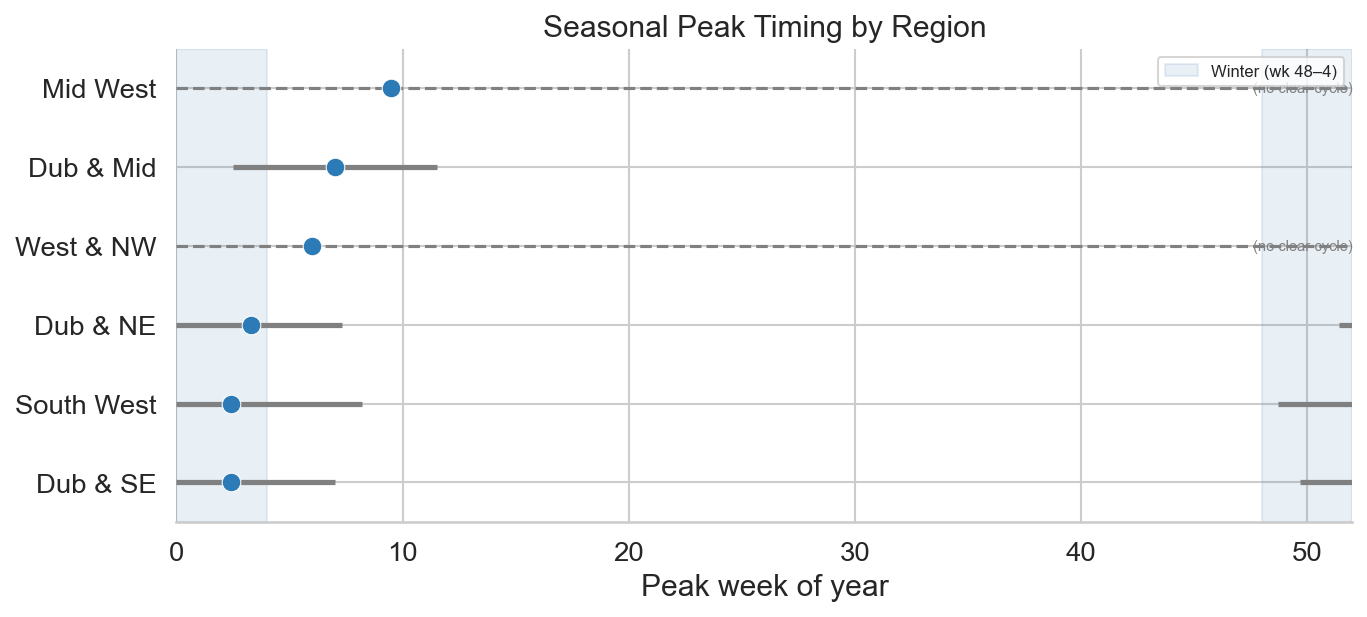

In [24]:
# Peak week forest plot
df_plot = df_phase_overall.sort_values('Mean Peak Week')

lo_wk = df_plot['2.5%'].values
hi_wk = df_plot['97.5%'].values

# Flag regions where CI spans > 40 weeks (effectively unidentifiable)
def ci_width(lo, hi):
    return (hi - lo) % 52

fig, ax = plt.subplots(figsize=(9, 4), dpi=150, layout='constrained')
y_pos = list(range(len(df_plot)))

# Winter band (weeks 48-52 + 1-4)
ax.axvspan(48, 52, alpha=0.12, color='steelblue', label='Winter (wk 48\u20134)')
ax.axvspan(0, 4, alpha=0.12, color='steelblue')

for y, lo, hi, region in zip(y_pos, lo_wk, hi_wk, df_plot['Region'].values):
    width = ci_width(lo, hi)
    if width > 40:  # unidentifiable — dashed, lighter
        style = dict(color='grey', linewidth=1.5, linestyle='--', zorder=1)
        ax.hlines(y, 0, 52, **style)
        ax.annotate('(no clear cycle)', xy=(52, y), fontsize=7,
                    color='grey', va='center', ha='right')
    elif lo <= hi:
        ax.hlines(y, lo, hi, color='grey', linewidth=2.5, zorder=2)
    else:  # wraps around week 0
        ax.hlines(y, lo, 52, color='grey', linewidth=2.5, zorder=2)
        ax.hlines(y, 0, hi, color='grey', linewidth=2.5, zorder=2)

ax.scatter(df_plot['Mean Peak Week'].values, y_pos, s=80, zorder=3,
           color='#2c7bb6', edgecolors='white', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels([short_names.get(r, r) for r in df_plot['Region'].values])
ax.set_xlabel('Peak week of year')
ax.set_xlim(0, 52)
ax.set_ylim(-0.5, len(y_pos) - 0.5)
ax.set_title('Seasonal Peak Timing by Region')
ax.legend(loc='upper right', fontsize=8)
sns.despine(left=True)
fig.savefig('../../data/models/v5/plots/seasonal_phase_test.png', bbox_inches='tight', dpi=150)
plt.show()

#### Bayes Factors vs posterior probability

$$BF = \frac{\text{posterior odds}}{\text{prior odds}}$$

Phase winter test:

$$\text{prior odds} = \frac{P(\text{winter})}{P(\neg\text{winter})} = \frac{9/52}{43/52} = \frac{9}{43}$$

$$\text{posterior odds} = \frac{P(\text{winter} \mid \text{data})}{P(\neg\text{winter} \mid \text{data})}$$

### Phase cycles — winter test

In [25]:
# Winter: weeks 48-52 or 1-4 (~Dec-Jan)  = 9 weeks
# Summer: weeks 22-30 (~Jun-Jul)          = 9 weeks
# BF = posterior odds / prior odds
# Prior odds assume uniform peak timing: P(winter) = 9/52
n_winter_weeks = 9  # 48,49,50,51,52,1,2,3,4
n_summer_weeks = 9  # 22,23,24,25,26,27,28,29,30
prior_winter = n_winter_weeks / 52
prior_summer = n_summer_weeks / 52

results = []
for i, region in enumerate(regions):
    b = raw_df[f'beta[{i+1}]'].values
    g = raw_df[f'gamma[{i+1}]'].values
    phase_rad = np.arctan2(g, b)
    peak_weeks = (52 / (2 * np.pi) * phase_rad) % 52

    # Mean in radian space then convert — averaging wrapped weeks directly
    # is invalid for circular data (e.g. mean([51, 1]) = 26, not ~0)
    mean_peak_wk = ((52 / (2 * np.pi)) * phase_rad.mean()) % 52

    prob_winter = ((peak_weeks >= 48) | (peak_weeks <= 4)).mean()
    prob_summer = ((peak_weeks >= 22) & (peak_weeks <= 30)).mean()

    # Bayes factors vs uniform prior
    post_odds_w = prob_winter / max(1 - prob_winter, 1e-10)
    prior_odds_w = prior_winter / (1 - prior_winter)
    bf_winter = post_odds_w / prior_odds_w

    post_odds_s = prob_summer / max(1 - prob_summer, 1e-10)
    prior_odds_s = prior_summer / (1 - prior_summer)
    bf_summer = post_odds_s / prior_odds_s

    results.append({
        'Region': region,
        'Mean peak week': round(mean_peak_wk, 2),
        'P(winter)': round(prob_winter, 3),
        'BF(winter)': round(bf_winter, 2),
        'P(summer)': round(prob_summer, 3),
        'BF(summer)': round(bf_summer, 2),
    })

df_season_phase_test = pd.DataFrame(results).sort_values('P(winter)', ascending=False)
df_season_phase_test.to_csv('../../data/models/v5/seasonal_phase_test.csv', index=False)
df_season_phase_test


,Region,Mean peak week,P(winter),BF(winter),P(summer),BF(summer)
2,HSE Dublin and South East,2.37,0.763,15.41,0.000,0.00
4,HSE South West,2.41,0.710,11.69,0.000,0.00
1,HSE Dublin and North East,3.33,0.639,8.45,0.000,0.00
5,HSE West and North West,5.97,0.229,1.42,0.046,0.23
0,HSE Dublin and Midlands,6.96,0.088,0.46,0.000,0.00
3,HSE Mid West,9.53,0.049,0.25,0.220,1.35


### Alpha baseline — pairwise test
Tests on $\alpha_i$ directly (the region intercepts).

In [26]:
alpha_samples = {regions[i]: raw_df[f'alpha[{i+1}]'].values for i in range(n_region)}

results = []
for r1, r2 in combinations(range(n_region), 2):
    diff = alpha_samples[regions[r1]] - alpha_samples[regions[r2]]
    ci_lower, ci_upper = np.quantile(diff, [0.025, 0.975])
    p_dir = (diff > 0).mean()
    p_abs = (np.abs(diff) > 0.5).mean()
    results.append({
        'Region1': regions[r1], 'Region2': regions[r2],
        'MeanDiff': diff.mean(),
        '2.5%': ci_lower,
        '97.5%': ci_upper,
        'P(|diff| > 0.5)': round(p_abs, 3),
        'P(diff > 0)': round(p_dir, 3),
        'P(diff < 0)': round(1 - p_dir, 3),
    })
df_alpha_pw_interc = pd.DataFrame(results).round(3)
df_alpha_pw_interc.to_csv('../../data/models/v5/alpha_pairwise.csv', index=False)
df_alpha_pw_interc


,Region1,Region2,MeanDiff,2.5%,97.5%,P(|diff| > 0.5),P(diff > 0),P(diff < 0)
0,HSE Dublin and Midlands,HSE Dublin and North East,1.704,1.241,2.165,1.000,1.000,0.000
1,HSE Dublin and Midlands,HSE Dublin and South East,1.001,0.523,1.480,0.980,1.000,0.000
2,HSE Dublin and Midlands,HSE Mid West,-4.180,-4.893,-3.453,1.000,0.000,1.000
3,HSE Dublin and Midlands,HSE South West,-0.419,-1.023,0.188,0.399,0.087,0.913
4,HSE Dublin and Midlands,HSE West and North West,-2.349,-2.996,-1.705,1.000,0.000,1.000
5,HSE Dublin and North East,HSE Dublin and South East,-0.703,-1.092,-0.315,0.850,0.000,1.000
6,HSE Dublin and North East,HSE Mid West,-5.884,-6.538,-5.218,1.000,0.000,1.000
7,HSE Dublin and North East,HSE South West,-2.123,-2.666,-1.574,1.000,0.000,1.000
8,HSE Dublin and North East,HSE West and North West,-4.054,-4.635,-3.469,1.000,0.000,1.000
9,HSE Dublin and South East,HSE Mid West,-5.181,-5.845,-4.507,1.000,0.000,1.000


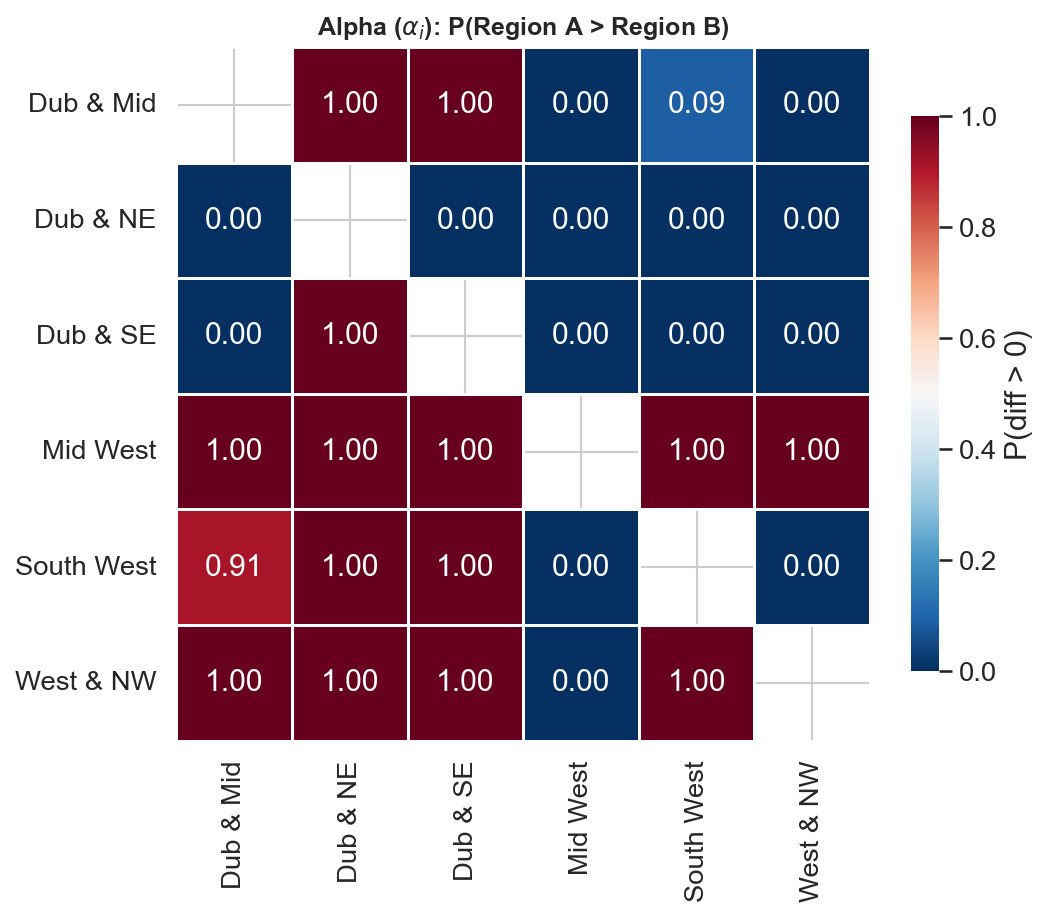

In [27]:
pairwise_heatmap(df_alpha_pw_interc, 'P(diff > 0)',
                 r'Alpha ($\alpha_i$): P(Region A > Region B)',
                 'alpha_pairwise')


### Cost coefficient $\mu_\lambda$
$$H_0: \mu_\lambda = 0 \quad H_a: \mu_\lambda \neq 0$$

Tests whether per-capita HR cost has a significant global relationship with the baseline trolley rate.
$\mu_\lambda > 0$ means higher per-capita spend is associated with higher trolley burden at baseline; $\mu_\lambda < 0$ would suggest higher-funded regions have lower burden.

In [28]:
# Per-region mu_lambda summary
rows = []
for i in range(n_region):
    vals = raw_df[f'mu_lambda[{i+1}]'].values
    scaled = vals * cost_per_10k[i]
    rows.append({
        'Region': regions[i],
        'BudgetPer10k_k': round(cost_per_10k[i], 4),
        'mu_lambda Mean': vals.mean(),
        'SD': vals.std(),
        '2.5%': np.quantile(vals, 0.025),
        '97.5%': np.quantile(vals, 0.975),
        'Scaled Cost (mu_lambda * c_i)': scaled.mean(),
    })

# Append mu_global summary row
rows.append({
    'Region': 'mu_global',
    'BudgetPer10k_k': np.nan,
    'mu_lambda Mean': mu_global_samples.mean(),
    'SD': mu_global_samples.std(),
    '2.5%': np.quantile(mu_global_samples, 0.025),
    '97.5%': np.quantile(mu_global_samples, 0.975),
    'Scaled Cost (mu_lambda * c_i)': np.nan,
})

df_mu_lambda = pd.DataFrame(rows).round(4)
df_mu_lambda.to_csv('../../data/models/v5/mu_lambda_summary.csv', index=False)
df_mu_lambda

,Region,BudgetPer10k_k,mu_lambda Mean,SD,2.5%,97.5%,Scaled Cost (mu_lambda * c_i)
0,HSE Dublin and Midlands,34.0559,0.1248,0.0331,0.0690,0.2074,4.2518
1,HSE Dublin and North East,28.5995,0.0963,0.0410,0.0389,0.2040,2.7537
2,HSE Dublin and South East,27.3815,0.1200,0.0378,0.0571,0.2155,3.2847
3,HSE Mid West,28.6158,0.2605,0.0501,0.1286,0.3204,7.4536
4,HSE South West,27.0316,0.1628,0.0357,0.0852,0.2382,4.3995
5,HSE West and North West,33.0678,0.1862,0.0332,0.1061,0.2466,6.1570
6,mu_global,NaN,0.1584,0.0431,0.0731,0.2448,NaN


### Phi AR(1) coefficient
- The carryover from the previous week

In [29]:
phi_df = pd.DataFrame(raw_df['phi'].values).round(4)
phi_df

,0
0,0.6360
1,0.6273
2,0.6470
3,0.6385
4,0.6541
...,...
119995,0.6335
119996,0.6448
119997,0.6673
119998,0.6912


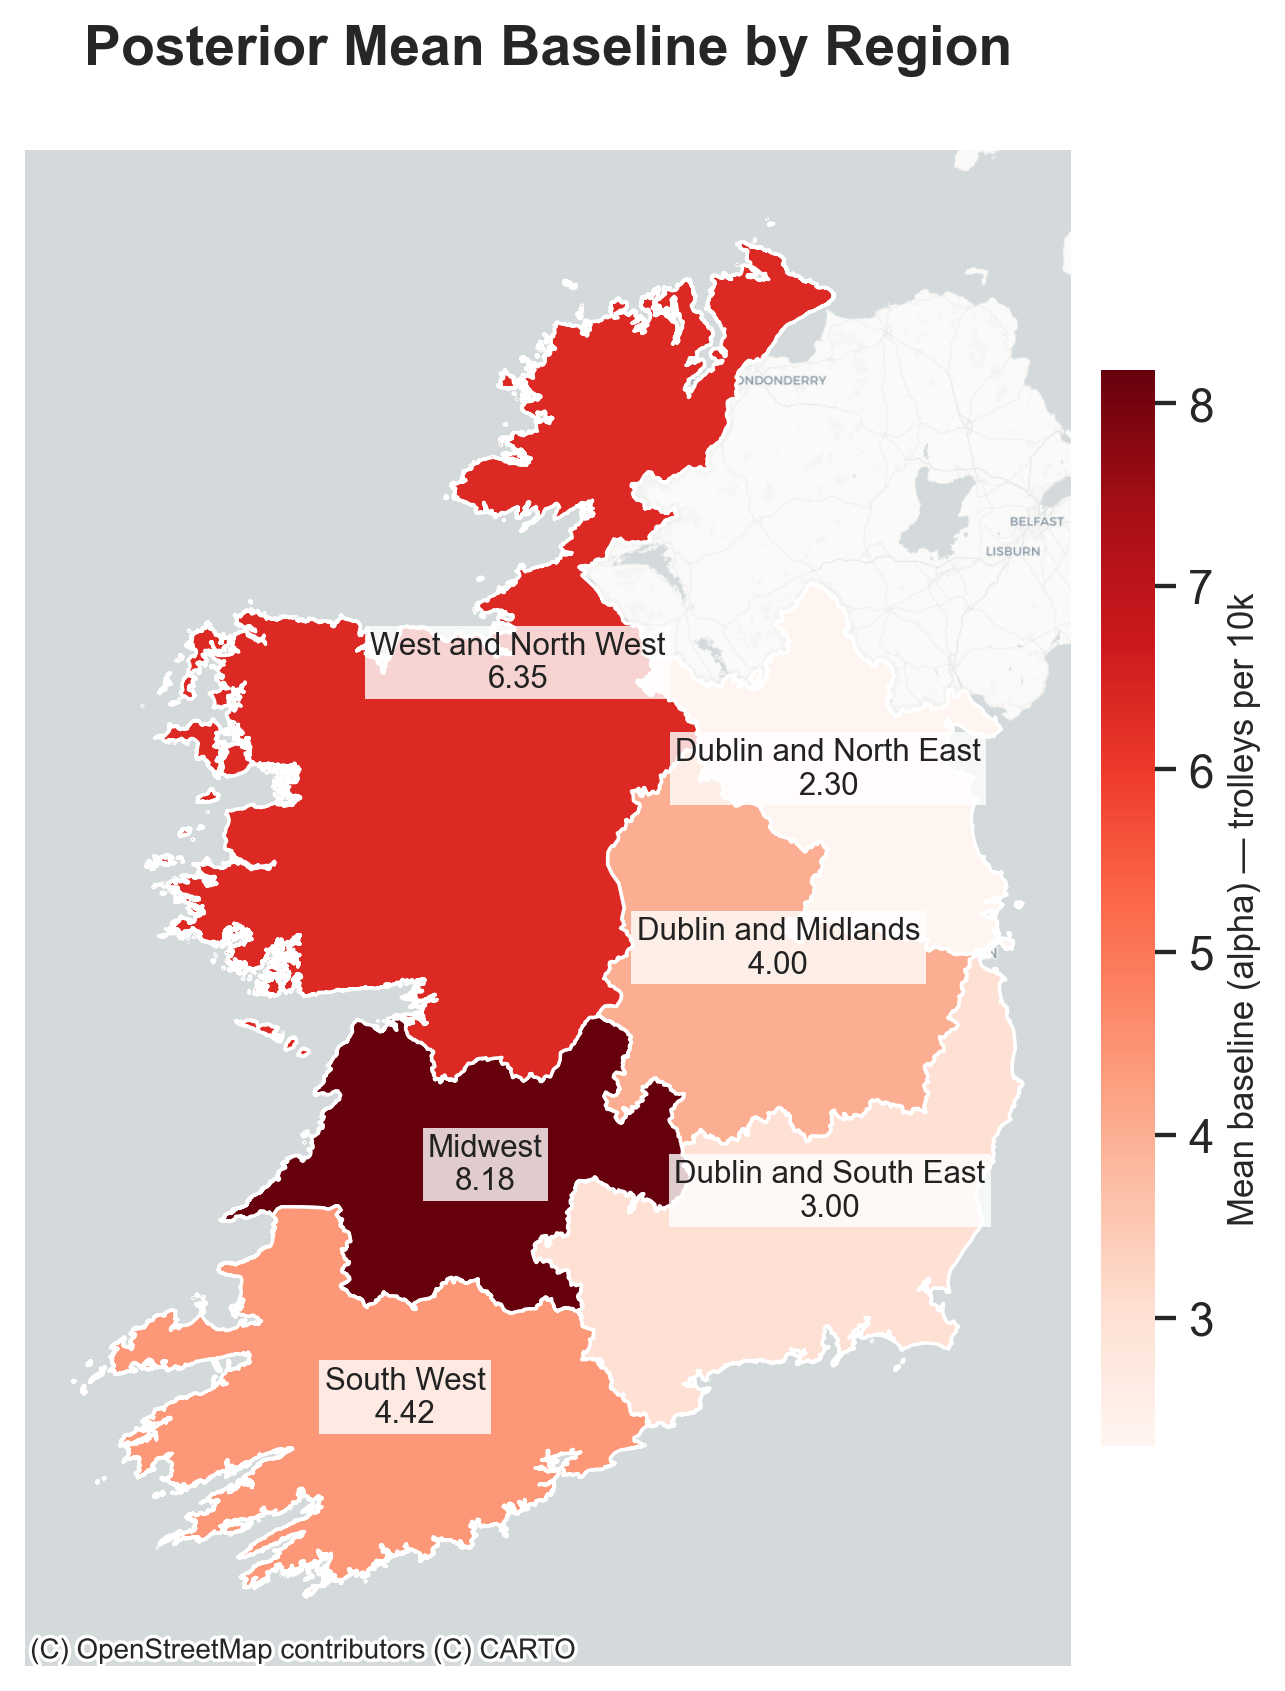

In [30]:
# Baseline (alpha) choropleth map
import geopandas as gpd
import matplotlib as mpl
import contextily as ctx

# Compute mean alpha per region from posterior samples
alpha_means = pd.DataFrame({
    'Region': regions,
    'mean_alpha': [raw_df[f'alpha[{i+1}]'].mean() for i in range(n_region)]
})
alpha_means['mean_alpha'] = alpha_means['mean_alpha'].round(2)

name_map = {
    'HSE Dublin and Midlands': 'HSE Dublin and Midlands HR',
    'HSE Dublin and North East': 'HSE Dublin and North East HR',
    'HSE Dublin and South East': 'HSE Dublin and South East HR',
    'HSE Mid West': 'HSE Midwest HR',
    'HSE South West': 'HSE South West HR',
    'HSE West and North West': 'HSE West and North West HR',
}
alpha_means['HR_operational_name'] = alpha_means['Region'].map(name_map)

gdf = gpd.read_file('../../data/mapping/hse_regions.geojson')
if gdf.crs is None:
    gdf = gdf.set_crs('EPSG:4326')
gdf = gdf.merge(alpha_means[['HR_operational_name', 'mean_alpha']], on='HR_operational_name', how='left')
gdf_3857 = gdf.to_crs(epsg=3857)
gdf_3857['label_point'] = gdf_3857.geometry.representative_point()

fig, ax = plt.subplots(figsize=(7, 7), dpi=250)
cmap = mpl.cm.Reds
vmin, vmax = float(gdf_3857['mean_alpha'].min()), float(gdf_3857['mean_alpha'].max())
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

gdf_3857.plot(column='mean_alpha', ax=ax, cmap=cmap, norm=norm, edgecolor='white', linewidth=1.0)

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
except Exception as e:
    print(f'Basemap skipped: {e}')

for _, row in gdf_3857.iterrows():
    if pd.isna(row['mean_alpha']):
        continue
    x, y = row['label_point'].x, row['label_point'].y
    short = row['HR_operational_name'].replace(' HR', '').replace('HSE ', '')
    label = f"{short}\n{row['mean_alpha']:.2f}"
    ax.text(x, y, label, ha='center', va='center', fontsize=9, color='#222',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1.5), zorder=5)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('Mean baseline (alpha) — trolleys per 10k', fontsize=10)
cbar.outline.set_visible(False)

ax.set_title('Posterior Mean Baseline by Region', fontsize=16, pad=12, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
fig.savefig('../../data/models/v5/plots/alpha_overall.png', bbox_inches='tight', dpi=150)
plt.show()


In [31]:
results = []
for i, region in enumerate(regions):
    vals = raw_df[f'alpha[{i+1}]'].values
    ci_lower, ci_upper = np.quantile(vals, [0.025, 0.975])
    results.append({
        'Region':     region,
        'Mean':       vals.mean(),
        'SD':         vals.std(),
        '2.5%':       ci_lower,
        '97.5%':      ci_upper,
        'Deviation':  vals.mean() - mu_alpha_mean,
    })

df_alpha_overall = pd.DataFrame(results).sort_values('Mean', ascending=False).round(3)
df_alpha_overall.to_csv('../../data/models/v5/alpha_overall.csv', index=False)
df_alpha_overall


NameError: name 'mu_alpha_mean' is not defined

### Alpha baseline — overall test
$$H_0: \alpha_i = 0 \quad H_a: \alpha_i \neq 0$$

Tests whether each region's baseline trolley rate is significantly different from zero.

### Alpha baseline — pairwise test (regional differences)
$$H_0: \alpha_i = \alpha_j \quad H_a: \alpha_i \neq \alpha_j$$

Tests whether baseline trolley rates differ significantly between pairs of regions.

In [ ]:
results = []
for r1, r2 in combinations(range(n_region), 2):
    diff = raw_df[f'alpha[{r1+1}]'].values - raw_df[f'alpha[{r2+1}]'].values
    ci_lower, ci_upper = np.quantile(diff, [0.025, 0.975])
    p_dir = (diff > 0).mean()
    p_abs = (np.abs(diff) > 0.5).mean()
    results.append({
        'Region1': regions[r1], 'Region2': regions[r2],
        'MeanDiff': diff.mean(),
        '2.5%': ci_lower,
        '97.5%': ci_upper,
        'P(|diff| > 0.5)': round(p_abs, 3),
        'P(diff > 0)': round(p_dir, 3),
        'P(diff < 0)': round(1 - p_dir, 3),
    })

df_alpha_pw = pd.DataFrame(results).round(3)
df_alpha_pw.to_csv('../../data/models/v5/alpha_cost_pairwise.csv', index=False)
df_alpha_pw


### New Year — delta (per-region)
V4 fits `delta_pre[i]`, `delta_mid[i]`, `delta_post[i]` per region (same as V3).

In [ ]:
delta_params = ['delta_pre', 'delta_mid', 'delta_post']
delta_samples = {}
for param in delta_params:
    delta_samples[param] = {}
    for i in range(n_region):
        delta_samples[param][regions[i]] = raw_df[f'{param}[{i+1}]'].values

In [ ]:
for param in delta_params:
    results = []
    for region in regions:
        vals = delta_samples[param][region]
        ci_lower, ci_upper = np.quantile(vals, [0.025, 0.975])
        results.append({
            'Region': region, 'Mean': vals.mean(),
            '2.5%': ci_lower,
            '97.5%': ci_upper,
            'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
        })
    df_sig = pd.DataFrame(results).sort_values('Mean', ascending=False).round(3)
    print(f'\n=== Overall: {param} ===')
    display(df_sig)
    df_sig.to_csv(f'../../data/models/v5/delta_overall_{param}.csv', index=False)

# Combined delta overall
delta_combined_rows = []
for param in delta_params:
    df_part = pd.read_csv(f'../../data/models/v5/delta_overall_{param}.csv')
    df_part.insert(0, 'Parameter', param.replace('delta_', '').title())
    delta_combined_rows.append(df_part)
df_delta_combined = pd.concat(delta_combined_rows, ignore_index=True)
df_delta_combined.to_csv('../../data/models/v5/delta_overall_combined.csv', index=False)


In [ ]:
short_names = {
    'HSE Dublin and Midlands': 'Dublin & Midlands',
    'HSE Dublin and North East': 'Dublin & NE',
    'HSE Dublin and South East': 'Dublin & SE',
    'HSE Mid West': 'Mid West',
    'HSE South West': 'South West',
    'HSE West and North West': 'West & NW',
}
labels_nice = {'delta_pre': 'Pre', 'delta_mid': 'Mid', 'delta_post': 'Post'}
x_labels = [labels_nice[p] for p in delta_params]

fig, axes = plt.subplots(3, 2, figsize=(12, 10), dpi=150, layout='constrained')
for idx, (region, ax) in enumerate(zip(regions, axes.flatten())):
    means  = np.array([delta_samples[p][region].mean() for p in delta_params])
    ci_lo  = np.array([np.quantile(delta_samples[p][region], 0.025) for p in delta_params])
    ci_hi  = np.array([np.quantile(delta_samples[p][region], 0.975) for p in delta_params])
    ax.errorbar(x_labels, means, yerr=[means - ci_lo, ci_hi - means],
                fmt='o-', linewidth=2, markersize=8, capsize=6, capthick=2, elinewidth=2, zorder=3)
    ax.axhline(0, linestyle='--', linewidth=1, alpha=0.6)
    ax.set_title(short_names.get(region, region), fontsize=10)
    ax.set_xlabel('New Year Period')
    ax.set_ylabel('Effect (trolleys per 10k)')
fig.suptitle('New Year Effects (delta) by Region — 95% CI', fontsize=14, fontweight='bold')
fig.savefig('../../data/models/v5/plots/delta_overall_combined.png', bbox_inches='tight', dpi=150)
plt.show()


### New Year — delta pairwise (per-region)

In [ ]:
for param in delta_params:
    results = []
    for r1, r2 in combinations(range(n_region), 2):
        diff = delta_samples[param][regions[r1]] - delta_samples[param][regions[r2]]
        ci_lower, ci_upper = np.quantile(diff, [0.025, 0.975])
        p_dir = (diff > 0).mean()
        p_abs = (np.abs(diff) > 0.5).mean()
        results.append({
            'Region1': regions[r1], 'Region2': regions[r2],
            'MeanDiff': diff.mean(),
            '2.5%': ci_lower,
            '97.5%': ci_upper,
            'P(|diff| > 0.5)': round(p_abs, 3),
            'P(diff > 0)': round(p_dir, 3),
            'P(diff < 0)': round(1 - p_dir, 3),
        })
    df_pw = pd.DataFrame(results).round(3)
    print(f'\n=== Pairwise: {param} ===')
    display(df_pw)
    df_pw.to_csv(f'../../data/models/v5/delta_pairwise_{param}.csv', index=False)

# Combined delta pairwise
delta_pw_combined_rows = []
for param in delta_params:
    df_part = pd.read_csv(f'../../data/models/v5/delta_pairwise_{param}.csv')
    df_part.insert(0, 'Parameter', param.replace('delta_', '').title())
    delta_pw_combined_rows.append(df_part)
df_delta_pw_combined = pd.concat(delta_pw_combined_rows, ignore_index=True)
df_delta_pw_combined.to_csv('../../data/models/v5/delta_pairwise_combined.csv', index=False)


In [ ]:
# Delta pairwise heatmaps — one per parameter
for param in delta_params:
    df_part = pd.read_csv(f'../../data/models/v5/delta_pairwise_{param}.csv')
    nice = param.replace('delta_', '').title()
    pairwise_heatmap(df_part, 'P(diff > 0)',
                     f'Delta {nice}: P(Region A > Region B)',
                     f'delta_pairwise_{param}')


### Full Reset — sigma (global, Mid West only)

In [ ]:
sigma_samples_global = raw_df[['sigma_pre', 'sigma_mid', 'sigma_post']]
sigma_params = ['sigma_pre', 'sigma_mid', 'sigma_post']

results = []
for param in sigma_params:
    vals = sigma_samples_global[param]
    ci_lower, ci_upper = np.quantile(vals, [0.025, 0.975])
    results.append({
        'Parameter': param, 'Mean': vals.mean(),
        '2.5%': ci_lower,
        '97.5%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
    })

df_sigma_ind = pd.DataFrame(results).round(3)
df_sigma_ind.to_csv('../../data/models/v5/full_reset_overall.csv', index=False)
df_sigma_ind


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=150, layout='constrained')
ax.errorbar(['Pre', 'Mid', 'Post'], df_sigma_ind['Mean'].values,
            yerr=[df_sigma_ind['Mean'].values - df_sigma_ind['2.5%'].values,
                  df_sigma_ind['97.5%'].values - df_sigma_ind['Mean'].values],
            fmt='o-', linewidth=2, markersize=8,
            capsize=6, capthick=2, elinewidth=2, zorder=3)
ax.axhline(0, linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('Full Reset Period')
ax.set_ylabel('Effect (trolleys per 10k)')
ax.set_title('Full Reset Effects — Mid West Only (95% CI)')
sns.despine(ax=ax)
fig.savefig('../../data/models/v5/plots/full_reset_overall.png', bbox_inches='tight', dpi=150)
plt.show()


In [ ]:
results = []
for a, b in combinations(sigma_params, 2):
    diff = sigma_samples_global[a] - sigma_samples_global[b]
    ci_lower, ci_upper = np.quantile(diff, [0.025, 0.975])
    p_dir = (diff > 0).mean()
    p_abs = (np.abs(diff) > 0.5).mean()
    results.append({
        'Comparison': f'{a} - {b}', 'MeanDiff': diff.mean(),
        '2.5%': ci_lower,
        '97.5%': ci_upper,
        'P(|diff| > 0.5)': round(p_abs, 3),
        'P(diff > 0)': round(p_dir, 3),
        'P(diff < 0)': round(1 - p_dir, 3),
    })
df_sigma_pw = pd.DataFrame(results).round(3)
df_sigma_pw


# Ranking
Ranked on $\alpha_i$ (region intercept) per MCMC draw.

Pandas ranking averages ties: 1, 2, 3, 3, 5 → 1, 2, 2.5, 2.5, 4, 5.

### Tables

In [ ]:
# Prior: uniform over 6 ranks -> P(rank=k) = 1/6 for any k

# Rank of the mean ranks (the point estimate ordering)
mean_ranks = ranked_alpha.mean(axis=0)
assigned_rank = mean_ranks.rank().astype(int)

rows = []
for region in ranked_alpha.columns:
    ranks = ranked_alpha[region]
    k = assigned_rank[region]
    p_k = (ranks == k).mean()
    rows.append({
        'Region': region,
        'Mean Rank': round(ranks.mean(), 2),
        'Assigned Rank': k,
        'P(assigned rank)': round(p_k, 3),
        'SD': round(ranks.std(), 2),
        '2.5%': ranks.quantile(.025),
        '97.5%': ranks.quantile(.975),
    })

final_ranked_df = pd.DataFrame(rows).sort_values('Mean Rank')
final_ranked_df.to_csv('../../data/models/v5/ranks.csv', index=False)
final_ranked_df


### Distributions of ranks

In [ ]:
# Rank distribution plot — proportion of posterior samples at each rank
short_names = {
    'HSE Dublin and Midlands': 'Dublin & Midlands',
    'HSE Dublin and North East': 'Dublin & North East',
    'HSE Dublin and South East': 'Dublin & South East',
    'HSE Mid West': 'Mid West',
    'HSE South West': 'South West',
    'HSE West and North West': 'West & North West',
}

n_samples = len(ranked_alpha)
fig, axes = plt.subplots(2, 3, figsize=(12, 6), dpi=150, layout='constrained', sharey=True)

for ax, col in zip(axes.flatten(), ranked_alpha.columns):
    # Compute proportions for each rank 1-6
    counts = ranked_alpha[col].value_counts().reindex(range(1, 7), fill_value=0)
    props = counts / n_samples

    bars = ax.bar(range(1, 7), props, color='#2c7bb6', edgecolor='white', linewidth=0.5)

    # Label bars with percentage (skip 0%)
    for bar, p in zip(bars, props):
        if p > 0.005:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{p:.0%}', ha='center', va='bottom', fontsize=8)

    ax.set_title(short_names.get(col, col), fontsize=10, fontweight='600')
    ax.set_xlabel('Rank', fontsize=8)
    ax.set_xticks(range(1, 7))
    ax.set_ylabel('Proportion' if ax in axes[:, 0] else '', fontsize=8)
    sns.despine(ax=ax)

fig.suptitle(r'Posterior Rank Distributions for $\alpha_i$', fontsize=14, fontweight='bold')
fig.savefig('../../data/models/v5/plots/ranks.png', bbox_inches='tight', dpi=150)
plt.show()


### Pairwise comparison

In [ ]:
lower_q = .025; upper_q = .975
pairwise_test_df = []
for x in combinations(regions, 2):
    difference = ranked_alpha[x[0]] - ranked_alpha[x[1]]
    quantile = np.quantile(difference, [lower_q, upper_q])
    pairwise_test_df.append({
        'Region(1) - Region(2)': f"{x[0]} - {x[1]}",
        'P(R1 > R2)': round((difference > 0).mean(), 3),
        '2.5%': quantile[0],
        '97.5%': quantile[1],
        'Significant': 'Yes' if quantile[0] > 0 or quantile[1] < 0 else 'No'
    })
pd.DataFrame(pairwise_test_df)